# 节点06：Attention 机制（Bahdanau 2015）

**目标**：从零实现加性注意力（Additive Attention），理解它如何解决 Seq2Seq 的信息瓶颈。

**依赖**：`numpy`、`matplotlib`（可选 `torch`）


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

np.random.seed(42)
matplotlib.rcParams['font.family'] = ['DejaVu Sans']


## 1. 信息瓶颈演示

传统 Seq2Seq 把所有信息压缩进一个固定大小向量 $c$。
我们用一个极简 RNN 来演示：随着序列变长，最终隐状态承载的"有效信息"会越来越少。


/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_46355/1879170128.py:31: UserWarning: Glyph 24207 (\N{CJK UNIFIED IDEOGRAPH-5E8F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_46355/1879170128.py:31: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_46355/1879170128.py:31: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_46355/1879170128.py:31: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_46355/1879170128.py:31: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4g

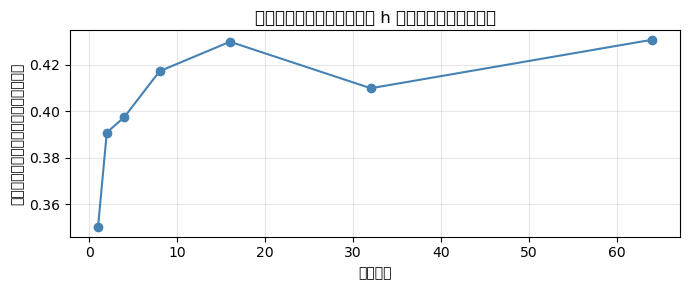

方差随序列长度变化： ['0.3500', '0.3907', '0.3975', '0.4172', '0.4299', '0.4098', '0.4307']


In [2]:
def simple_rnn_step(h, x, W_h, W_x, b):
    return np.tanh(W_h @ h + W_x @ x + b)

hidden_size = 4
input_size = 4
W_h = np.random.randn(hidden_size, hidden_size) * 0.5
W_x = np.random.randn(hidden_size, input_size) * 0.5
b = np.zeros(hidden_size)

# 用不同长度的序列，观察最终隐状态的方差（信息丰富度的代理指标）
seq_lengths = [1, 2, 4, 8, 16, 32, 64]
final_h_vars = []

for seq_len in seq_lengths:
    trials = []
    for _ in range(100):  # 100 次随机序列
        xs = np.random.randn(seq_len, input_size)
        h = np.zeros(hidden_size)
        for x in xs:
            h = simple_rnn_step(h, x, W_h, W_x, b)
        trials.append(h)
    # 不同序列的最终 h 方差（越小说明越"压缩"到固定范围，信息差异消失）
    final_h_vars.append(np.var(np.stack(trials), axis=0).mean())

plt.figure(figsize=(7, 3))
plt.plot(seq_lengths, final_h_vars, 'o-', color='steelblue')
plt.xlabel('序列长度')
plt.ylabel('最终隐状态方差（不同输入序列之间）')
plt.title('信息瓶颈：序列越长，最终 h 越趋同（区分度下降）')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../docs/assets/06_bottleneck.png', dpi=100)
plt.show()
print('方差随序列长度变化：', [f'{v:.4f}' for v in final_h_vars])


## 2. 手撕 Bahdanau 加性注意力

三步：**对齐分数 → Softmax → Context Vector**

$$e_{ij} = \mathbf{v}^T \tanh(\mathbf{W}_a \mathbf{s}_{i-1} + \mathbf{U}_a \mathbf{h}_j)$$

$$\alpha_{ij} = \text{softmax}(e_{ij})$$

$$\mathbf{c}_i = \sum_j \alpha_{ij} \cdot \mathbf{h}_j$$


In [3]:
def softmax(x):
    """数值稳定版 softmax：先减去最大值，防止指数溢出。"""
    x_shifted = x - np.max(x)
    e = np.exp(x_shifted)
    return e / e.sum()


class BahdanauAttention:
    """加性注意力（Bahdanau 2015）。
    
    参数:
        encoder_size: 编码器隐状态维度
        decoder_size: 解码器隐状态维度
        attn_size:    对齐网络的中间维度
    """
    def __init__(self, encoder_size, decoder_size, attn_size):
        # 学习到的参数（实际训练时通过梯度更新；这里随机初始化用于演示）
        self.W_a = np.random.randn(attn_size, decoder_size) * 0.1
        self.U_a = np.random.randn(attn_size, encoder_size) * 0.1
        self.v = np.random.randn(attn_size) * 0.1

    def alignment_scores(self, s_prev, encoder_states):
        """计算对齐分数 e_j for j in 0..T-1.
        
        Args:
            s_prev:         解码器上一步隐状态，形状 (decoder_size,)
            encoder_states: 编码器所有隐状态，形状 (T, encoder_size)
        Returns:
            scores: 形状 (T,)
        """
        T = encoder_states.shape[0]
        # W_a @ s_prev: (attn_size,)  — 与 T 无关，广播
        dec_part = self.W_a @ s_prev  # (attn_size,)
        scores = np.zeros(T)
        for j in range(T):
            enc_part = self.U_a @ encoder_states[j]  # (attn_size,)
            scores[j] = self.v @ np.tanh(dec_part + enc_part)
        return scores

    def forward(self, s_prev, encoder_states):
        """完整的注意力前向传播。
        
        Returns:
            context: 形状 (encoder_size,)
            alpha:   注意力权重，形状 (T,)
        """
        scores = self.alignment_scores(s_prev, encoder_states)
        alpha = softmax(scores)               # (T,)
        context = alpha @ encoder_states       # (encoder_size,)
        return context, alpha


# ── 快速测试 ──────────────────────────────────────────────────────────────────
enc_size, dec_size, attn_size = 8, 6, 10
T = 5  # 编码器序列长度

attn = BahdanauAttention(enc_size, dec_size, attn_size)
encoder_states = np.random.randn(T, enc_size)
s_prev = np.random.randn(dec_size)

context, alpha = attn.forward(s_prev, encoder_states)

print(f'encoder_states: {encoder_states.shape}')
print(f's_prev:         {s_prev.shape}')
print(f'context:        {context.shape}')
print(f'alpha (sum={alpha.sum():.4f}): {alpha.round(4)}')
assert alpha.shape == (T,), 'alpha 形状错误'
assert abs(alpha.sum() - 1.0) < 1e-9, 'alpha 不是概率分布'
assert context.shape == (enc_size,), 'context 形状错误'
print('✓ 形状验证通过')


encoder_states: (5, 8)
s_prev:         (6,)
context:        (8,)
alpha (sum=1.0000): [0.1836 0.2002 0.1921 0.194  0.23  ]
✓ 形状验证通过


## 3. Softmax 性质验证

Softmax 有两个关键性质：
1. **非负**：所有输出 ≥ 0
2. **归一**：所有输出之和 = 1


大数值输入: [1000. 1001.  999.]
Softmax 输出: [0.2447 0.6652 0.09  ]
输出之和: 1.000000


/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_46355/906603898.py:21: UserWarning: Glyph 36755 (\N{CJK UNIFIED IDEOGRAPH-8F93}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_46355/906603898.py:21: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_46355/906603898.py:21: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_46355/906603898.py:21: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_46355/906603898.py:21: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0

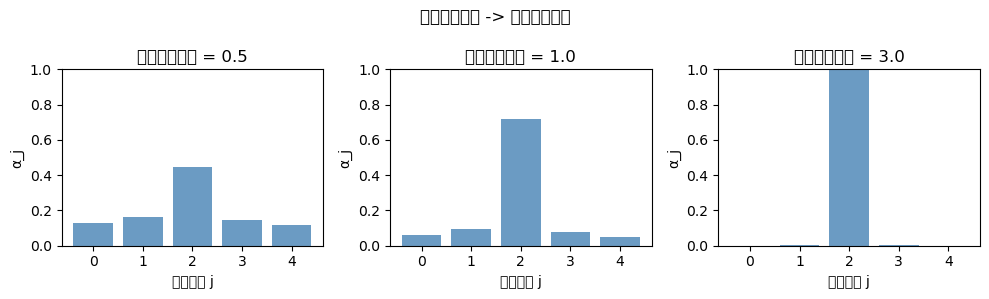

✓ Softmax 数值稳定性验证通过


In [4]:
# 验证数值稳定性：即使输入很大也不溢出
large_input = np.array([1000.0, 1001.0, 999.0])
result = softmax(large_input)
print(f'大数值输入: {large_input}')
print(f'Softmax 输出: {result.round(4)}')
print(f'输出之和: {result.sum():.6f}')
assert np.all(result >= 0), '输出有负值'
assert abs(result.sum() - 1.0) < 1e-9, '输出之和不为 1'

# 一个直觉演示：不同"尖锐度"的分数
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
base_scores = np.array([0.5, 1.0, 3.0, 0.8, 0.3])
for ax, scale in zip(axes, [0.5, 1.0, 3.0]):
    weights = softmax(base_scores * scale)
    ax.bar(range(5), weights, color='steelblue', alpha=0.8)
    ax.set_title(f'分数放大倍数 = {scale}')
    ax.set_ylim(0, 1)
    ax.set_xlabel('输入位置 j')
    ax.set_ylabel('α_j')
plt.suptitle('放大对齐分数 -> 注意力更专注', fontsize=12)
plt.tight_layout()
plt.savefig('../docs/assets/06_softmax_sharpness.png', dpi=100)
plt.show()
print('✓ Softmax 数值稳定性验证通过')


## 4. 玩具任务：序列复制中的注意力

任务：输入序列 `[a, b, c, d, e]`，输出应该按顺序复制 `[a, b, c, d, e]`。
理想情况下，生成第 $i$ 个输出时，注意力应集中在输入的第 $i$ 个位置（对角线注意力）。

这里我们用**随机初始化**的注意力来演示基线（未经训练），
然后手动设置'完美对齐'的参数来展示理想情况。


/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_46355/501964330.py:34: UserWarning: Glyph 32534 (\N{CJK UNIFIED IDEOGRAPH-7F16}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_46355/501964330.py:34: UserWarning: Glyph 30721 (\N{CJK UNIFIED IDEOGRAPH-7801}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_46355/501964330.py:34: UserWarning: Glyph 22120 (\N{CJK UNIFIED IDEOGRAPH-5668}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_46355/501964330.py:34: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_46355/501964330.py:34: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30721 (\N{CJK UNIFIED IDEOGRAPH-7801}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22120 (\N{CJK UNIFIED IDEOGRAPH-5668}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39588 (\N{CJK UNIFIED IDEOGRAPH-9AA4}) missing from font(s) DejaV

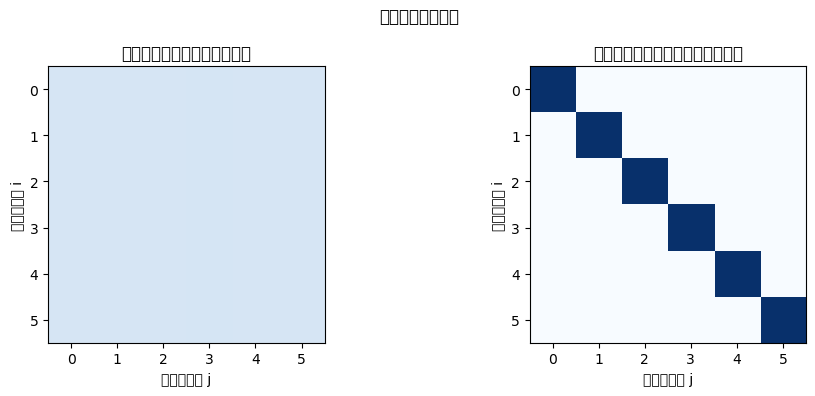

注意力矩阵可视化完成


In [5]:
# 手工演示'完美对角注意力'
T_demo = 6
# 创建简单的输入 embedding（每个位置一个 one-hot 向量）
encoder_states_demo = np.eye(T_demo)  # (T, T)：每行是一个位置的 embedding

# 用不同的解码器隐状态（模拟对不同目标词的查询）
# 理想：解码第 i 个词时，s_prev 和 encoder_states[i] 最相似
alpha_matrix = np.zeros((T_demo, T_demo))

attn_demo = BahdanauAttention(encoder_size=T_demo, decoder_size=T_demo, attn_size=T_demo)

# 随机解码器状态 → 随机注意力
for i in range(T_demo):
    s = np.random.randn(T_demo)  # 随机解码器状态
    _, alpha = attn_demo.forward(s, encoder_states_demo)
    alpha_matrix[i] = alpha

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 未训练的随机注意力
axes[0].imshow(alpha_matrix, cmap='Blues', vmin=0, vmax=1)
axes[0].set_title('随机初始化注意力（未训练）')
axes[0].set_xlabel('编码器位置 j')
axes[0].set_ylabel('解码器步骤 i')

# 理想的对角注意力（用 eye 模拟训练后的结果）
ideal_alpha = np.eye(T_demo)
axes[1].imshow(ideal_alpha, cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('理想的对角注意力（训练后目标）')
axes[1].set_xlabel('编码器位置 j')
axes[1].set_ylabel('解码器步骤 i')

plt.suptitle('注意力矩阵可视化', fontsize=12)
plt.tight_layout()
plt.savefig('../docs/assets/06_attention_heatmap.png', dpi=100)
plt.show()
print('注意力矩阵可视化完成')


## 5. 特殊情况验证

**命题**：如果注意力权重 $\alpha$ 是 one-hot 的（只有一个位置为 1，其余为 0），
那么 context vector 就等于对应编码器位置的隐状态。


In [6]:
enc_states = np.random.randn(5, 8)

# one-hot alpha: 第 2 个位置
alpha_onehot = np.zeros(5)
alpha_onehot[2] = 1.0

context_manual = alpha_onehot @ enc_states
expected = enc_states[2]

print(f'one-hot alpha: {alpha_onehot}')
print(f'context_manual: {context_manual.round(4)}')
print(f'enc_states[2]:  {expected.round(4)}')
assert np.allclose(context_manual, expected), 'one-hot 验证失败'
print('✓ one-hot 注意力时 context = 对应编码器状态（数学正确）')

# 均匀 alpha: context = 编码器隐状态的均值
alpha_uniform = np.ones(5) / 5
context_uniform = alpha_uniform @ enc_states
expected_mean = enc_states.mean(axis=0)
assert np.allclose(context_uniform, expected_mean), '均匀 alpha 验证失败'
print('✓ 均匀注意力时 context = 编码器状态均值（数学正确）')


one-hot alpha: [0. 0. 1. 0. 0.]
context_manual: [-1.8385  1.48   -0.4387  0.9854 -0.6564  0.9867 -0.4286 -1.2105]
enc_states[2]:  [-1.8385  1.48   -0.4387  0.9854 -0.6564  0.9867 -0.4286 -1.2105]
✓ one-hot 注意力时 context = 对应编码器状态（数学正确）
✓ 均匀注意力时 context = 编码器状态均值（数学正确）


## 6. PyTorch 对比

`torch.nn.MultiheadAttention` 实现的是**缩放点积注意力**（Scaled Dot-Product Attention），
和 Bahdanau 加性注意力有所不同，但核心思路一致：分数 → softmax → 加权求和。


In [7]:
try:
    import torch
    import torch.nn as nn

    # MultiheadAttention 期望 (seq_len, batch, embed_dim)
    seq_len, batch, embed_dim = 5, 1, 8
    mha = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=1, batch_first=False)

    query = torch.randn(1, batch, embed_dim)  # 单步 query
    key = torch.randn(seq_len, batch, embed_dim)
    value = key.clone()

    with torch.no_grad():
        output, attn_weights = mha(query, key, value)

    print(f'PyTorch MHA output shape: {output.shape}')
    print(f'PyTorch attn_weights shape: {attn_weights.shape}')
    print(f'attn_weights sum: {attn_weights.sum().item():.4f}')
    print('✓ PyTorch MultiheadAttention 验证通过')
except ImportError:
    print('PyTorch 未安装，跳过对比验证（纯 NumPy 实现已验证）')


PyTorch 未安装，跳过对比验证（纯 NumPy 实现已验证）
